In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 🧠 Deep Learning Models for Network Intrusion Detection

This notebook presents the implementation and evaluation of Deep Learning models for multi-class network intrusion detection using the CICDDoS2019 dataset.

The objective is to classify different types of DDoS attacks and benign traffic using Deep Neural Networks (DNN).

## 📚 Importing Required Libraries

The following libraries are used for:
- data manipulation
- deep learning model construction
- model evaluation
- visualization of results

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import joblib


from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization,
    Input
)

from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras import backend as K
from tensorflow.keras.callbacks import ReduceLROnPlateau

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    BatchNormalization,
    Input
)

## 🧹 Clearing Previous TensorFlow Sessions

TensorFlow sessions are cleared before training in order to:
- free memory
- avoid conflicts between previous models
- ensure a clean training environment

In [29]:
# Clear previous TensorFlow sessions
K.clear_session()

## 💾 Loading Preprocessed Datasets

The preprocessed datasets generated during the preprocessing phase are loaded for model training and evaluation.

The datasets have already undergone:
- feature cleaning
- normalization
- label encoding
- class balancing using SMOTE

In [55]:
X_train = np.load(
    '/content/drive/MyDrive/IDS_Project/data/X_train.npy'
)

y_train = np.load(
    '/content/drive/MyDrive/IDS_Project/data/y_train.npy'
)

X_test = np.load(
    '/content/drive/MyDrive/IDS_Project/data/X_test.npy'
)

y_test = np.load(
    '/content/drive/MyDrive/IDS_Project/data/y_test.npy'
)

In [56]:
)

label_encoder = joblib.load(
    '/content/drive/MyDrive/IDS_Project/data/label_encoder.pkl'
)

## 📏 Verifying Dataset Shapes

This step verifies:
- the dimensions of the training and testing datasets
- the consistency between features and labels

In [52]:
print(X_train.shape)
print(y_train.shape)

print(X_test.shape)
print(y_test.shape)

(136787, 27)
(136787,)
(40568, 27)
(40568,)


## 🔀 Train-Validation Split

The training dataset is divided into:
- training subset
- validation subset

The validation set is used to monitor the model performance during training and reduce overfitting.

In [32]:
X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    stratify=y_train,
    random_state=42
)

## 🏗️ Building the Deep Neural Network (DNN)

A Deep Neural Network architecture is designed for multi-class intrusion detection.

The model uses:
- Dense layers for feature learning
- Batch Normalization for training stability
- Dropout layers for regularization and overfitting reduction
- Softmax activation for multi-class classification

In [33]:
# Build Deep Neural Network model
model_dnn = Sequential([

    Input(shape=(X_train.shape[1],)),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.2),

    Dense(7, activation='softmax')

])

In [16]:
model_dnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,423 (204.78 KB)

 Trainable params: 51,527 (201.28 KB)

 Non-trainable params: 896 (3.50 KB)

## ⚙️ Compiling the Model

The model is compiled using:
- Adam optimizer
- Sparse categorical cross-entropy loss
- Accuracy as evaluation metric

These configurations are suitable for multi-class classification problems.

In [34]:
model_dnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## 📌 Configuring Training Callbacks

Callbacks are used to improve the training process:

- EarlyStopping prevents overfitting by stopping training when validation performance stops improving.
- ModelCheckpoint saves the best performing model during training.

In [35]:
# Save best model
checkpoint = ModelCheckpoint(
    filepath='best_dnn_model_7_classes.h5',
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

## 🚀 Training the DNN Model

The model is trained using:
- the preprocessed training dataset
- validation monitoring
- mini-batch gradient descent

Training performance is monitored across multiple epochs.

In [36]:
# Train model
history = model_dnn.fit(

    X_train_split,
    y_train_split,

    validation_data=(
        X_val_split,
        y_val_split
    ),

    epochs=20,
    batch_size=128,

    callbacks=[
    early_stop,
    checkpoint,
    reduce_lr
],

    verbose=1
)

Epoch 1/20
854/855 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6384 - loss: 0.7746
Epoch 1: val_accuracy improved from None to 0.70199, saving model to best_dnn_model_7_classes.h5



Epoch 1: finished saving model to best_dnn_model_7_classes.h5
855/855 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.6743 - loss: 0.6328 - val_accuracy: 0.7020 - val_loss: 0.5323 - learning_rate: 0.0010
Epoch 2/20
852/855 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6981 - loss: 0.5511
Epoch 2: val_accuracy improved from 0.70199 to 0.70444, saving model to best_dnn_model_7_classes.h5



Epoch 2: finished saving model to best_dnn_model_7_classes.h5
855/855 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6975 - loss: 0.5474 - val_accuracy: 0.7044 - val_loss: 0.5181 - learning_rate: 0.0010
Epoch 3/20
852/855 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7015 - loss: 0.5334
Epoch 3: val_accuracy improved from 0.70444 to 0.71204, saving model to best_dnn_model_7_classes.h5



Epoch 3: finished saving model to best_dnn_model_7_classes.h5
855/855 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7013 - loss: 0.5349 - val_accuracy: 0.7120 - val_loss: 0.5133 - learning_rate: 0.0010
Epoch 4/20
852/855 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7054 - loss: 0.5277
Epoch 4: val_accuracy did not improve from 0.71204
855/855 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7042 - loss: 0.5287 - val_accuracy: 0.7002 - val_loss: 0.5089 - learning_rate: 0.0010
Epoch 5/20
855/855 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7006 - loss: 0.5286
Epoch 5: val_accuracy did not improve from 0.71204
855/855 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7041 - loss: 0.5261 - val_accuracy: 0.7016 - val_loss: 0.5111 - learning_rate: 0.0010
Epoch 6/20
855/855 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7059 - loss: 0.5216
Epoch 6: val_accuracy did not improve from 0.71204
855/855 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.7054 - loss: 0.5238 - val_accuracy: 0.7000 - val


Epoch 7: finished saving model to best_dnn_model_7_classes.h5
855/855 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.7059 - loss: 0.5222 - val_accuracy: 0.7153 - val_loss: 0.5118 - learning_rate: 0.0010
Epoch 8/20
849/855 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7077 - loss: 0.5209
Epoch 8: val_accuracy did not improve from 0.71533
855/855 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7071 - loss: 0.5204 - val_accuracy: 0.7119 - val_loss: 0.5049 - learning_rate: 0.0010
Epoch 9/20
855/855 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7072 - loss: 0.5205
Epoch 9: val_accuracy did not improve from 0.71533
855/855 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.7088 - loss: 0.5186 - val_accuracy: 0.7090 - val_loss: 0.5037 - learning_rate: 0.0010
Epoch 10/20
852/855 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7090 - loss: 0.5168
Epoch 10: val_accuracy did not improve from 0.71533
855/855 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7089 - loss: 0.5175 - val_accuracy: 0.7134 -


Epoch 16: finished saving model to best_dnn_model_7_classes.h5
855/855 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7083 - loss: 0.5134 - val_accuracy: 0.7160 - val_loss: 0.5019 - learning_rate: 0.0010
Epoch 17/20
854/855 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7116 - loss: 0.5137
Epoch 17: val_accuracy did not improve from 0.71602
855/855 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7106 - loss: 0.5132 - val_accuracy: 0.7094 - val_loss: 0.5028 - learning_rate: 0.0010
Epoch 18/20
848/855 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7087 - loss: 0.5140
Epoch 18: val_accuracy did not improve from 0.71602

Epoch 18: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
855/855 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.7098 - loss: 0.5130 - val_accuracy: 0.7092 - val_loss: 0.5024 - learning_rate: 0.0010
Epoch 19/20
855/855 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7095 - loss: 0.5115
Epoch 19: val_accuracy did not improve from 0.71602
855/855 ━━━━━━━━━━

## 📊 Model Evaluation

The trained model is evaluated on the test dataset in order to measure:
- classification performance
- generalization capability
- prediction accuracy on unseen data

In [37]:
# Final evaluation on test dataset
test_loss, test_accuracy = model_dnn.evaluate(
    X_test,
    y_test,
    verbose=0
)

print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.9116
Test Loss: 0.4139


## 🔮 Generating Predictions

The trained model generates predictions on the test dataset.

The predicted probabilities are converted into final class predictions using the highest probability scores.

In [38]:
# Predictions
y_pred_probs = model_dnn.predict(X_test)

y_pred = np.argmax(
    y_pred_probs,
    axis=1
)

1268/1268 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step


## 📄 Classification Report

The classification report provides detailed evaluation metrics including:
- precision
- recall
- F1-score
- support

for each attack category.

In [39]:
class_names = label_encoder.classes_

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

               precision    recall  f1-score   support

       BENIGN       0.95      0.99      0.97     10873
   DrDoS_LDAP       0.83      0.97      0.89       978
  DrDoS_MSSQL       0.39      0.12      0.18      1860
DrDoS_NetBIOS       0.02      0.06      0.03       503
    DrDoS_UDP       1.00      0.88      0.94      8602
          Syn       1.00      1.00      1.00     17297
      UDP-lag       0.23      0.45      0.30       455

     accuracy                           0.91     40568
    macro avg       0.63      0.64      0.62     40568
 weighted avg       0.93      0.91      0.92     40568



## 📌 Confusion Matrix

The confusion matrix visualizes:
- correctly classified samples
- misclassified samples
- model performance across all attack categories

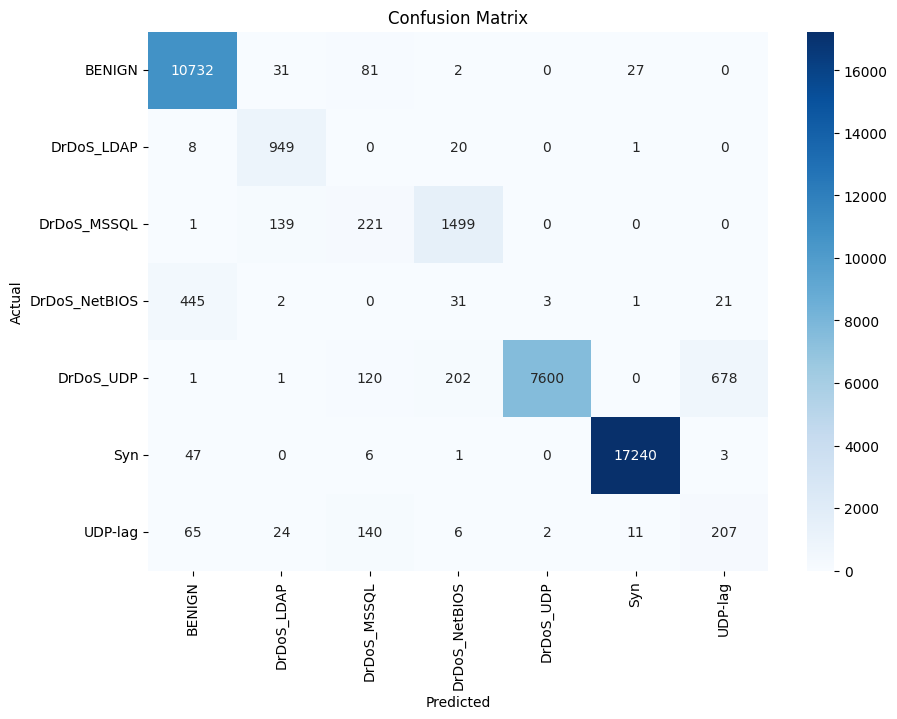

In [40]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## 📈 Training and Validation Curves

Training curves are plotted to visualize:
- training accuracy
- validation accuracy
- learning behavior across epochs

These plots help identify:
- overfitting
- underfitting
- convergence quality

In [48]:
# Plot training history
plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'],
         label='Train Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.title('Model DNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.show()

AttributeError: 'dict' object has no attribute 'history'

<Figure size 1000x500 with 0 Axes>

## 💾 Saving the Trained Model

The trained DNN model is saved for:
- future inference
- deployment
- reproducibility
- comparison with other architectures

In [53]:
with open('DNN_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

AttributeError: 'dict' object has no attribute 'history'

EOFError: Ran out of input

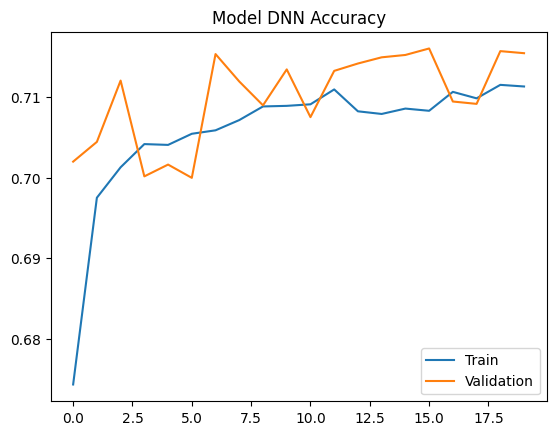

In [49]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.legend(['Train', 'Validation'])
plt.title('Model DNN Accuracy')

plt.show()

In [50]:
metrics = {
    "accuracy": test_accuracy,
    "loss": test_loss
}

with open('DNN_metrics.pkl', 'wb') as f:
    pickle.dump(metrics, f)

In [51]:
np.save('DNN_pred.npy', y_pred)